In [335]:
# Librerías usuales
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from datetime import datetime
import os
import json

# Encoder sklearn
from sklearn.preprocessing import LabelEncoder

# Train test
from sklearn.model_selection import train_test_split

PYTORCH_ENABLE_MPS_FALLBACK=1

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

In [336]:
# Ver el path actual
print("Directorio actual ", os.getcwd())

Directorio actual  /Users/diegoolguin/ChileMexicoData/codes/neural_networks


In [337]:
# GPU
if torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Usando dispositivo:", device)

Usando dispositivo: mps


In [338]:
dss_data = pd.read_csv("dss_mexico_cdmx.csv")
dss_data = dss_data.drop(columns=["REZAGO_SOCIAL_1"])

# Convertir categórico a numérico
label_encoder = LabelEncoder()
cat_columns = ["MARGINACION"]

dss_columns_del = ["POB_EDAD_0_14", "POB_EDAD_15_64", "POB_EDAD_65+",]
dss_data["MARGINACION"] = label_encoder.fit_transform(dss_data["MARGINACION"])
dss_data = dss_data.drop(columns=dss_columns_del)

cases_data = pd.read_csv("cdmx_casos.csv")
cases_data['NOM_MUN'] = cases_data['Unnamed: 0']
cases_data = cases_data.drop(columns=["Unnamed: 0"])

In [339]:
n_det = dss_data.shape[1] - 2
n_coms = cases_data.shape[0]
window_size = 7
data_windows = []
data_determinats = []
data_times = []
data_output = []
data_initial = []
y_initial_susceptible = []
y_initial_infected = []
y_initial_recovered = []


for i in range(n_coms):
    data_ = cases_data.loc[1][:-1].to_numpy()
    windows = np.lib.stride_tricks.sliding_window_view(data_, window_shape=window_size)
    input = windows[:-1]
    output = windows[1:,-1]
    initial = windows[0]

    data_windows.append(input)
    data_output.append(output)

    n_windows = data_windows[0].shape[0]
    data_determinats.append(np.repeat(dss_data.iloc[i][2:].to_numpy().reshape(1,-1),n_windows , 0))

    data_times.append(np.arange(window_size, window_size+n_windows, dtype=np.float32).reshape(-1,1))

    data_initial.append(np.concatenate((dss_data.iloc[i][2:].to_numpy(), initial, np.array([0.]))))
    y_initial_susceptible.append(dss_data.iloc[i]['POBTOT'])
    y_initial_infected.append(0)
    y_initial_recovered.append(0)


data_windows = np.concatenate(data_windows).astype(np.float32)
data_determinats = np.concatenate(data_determinats).astype(np.float32)
data_times = np.concatenate(data_times).astype(np.float32)
data_initial = np.array(data_initial).astype(np.float32)
y_initial_susceptible = np.array(y_initial_susceptible).astype(np.float32).reshape(-1,1)
y_initial_infected = np.array(y_initial_infected).astype(np.float32).reshape(-1,1)
y_initial_recovered = np.array(y_initial_recovered).astype(np.float32).reshape(-1,1)

In [340]:
X = np.concatenate((data_determinats, data_windows, data_times), axis=1)
y = np.concatenate(data_output).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dets_train, wins_train, times_train = X_train[:, :n_det], X_train[:, n_det:-1], X_train[:, -1]
dets_test, wins_test, times_test = X_test[:, :n_det], X_test[:, n_det:-1], X_test[:, -1]

dets_train_tensor = torch.tensor(dets_train, dtype=torch.float32)
dets_test_tensor = torch.tensor(dets_test, dtype=torch.float32)

wins_train_tensor = torch.tensor(wins_train, dtype=torch.float32)
wins_test_tensor = torch.tensor(wins_test, dtype=torch.float32)

times_train_tensor = torch.tensor(times_train, dtype=torch.float32).unsqueeze(1).requires_grad_(True)
times_test_tensor = torch.tensor(times_test, dtype=torch.float32).unsqueeze(1).requires_grad_(True)

X_train_tensor = torch.concatenate((dets_train_tensor, wins_train_tensor, times_train_tensor), axis=1)
X_test_tensor = torch.concatenate((dets_test_tensor, wins_test_tensor, times_test_tensor), axis=1)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = torch.utils.data.TensorDataset(dets_train_tensor,
                                               wins_train_tensor,
                                               times_train_tensor,
                                               y_train_tensor)

test_dataset = torch.utils.data.TensorDataset(dets_test_tensor,
                                              wins_test_tensor,
                                              times_test_tensor,
                                              y_test_tensor)

batch_size = 32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

input_initial = torch.tensor(data_initial, dtype=torch.float32)
y_initial = torch.tensor(np.concatenate((y_initial_susceptible, y_initial_infected, y_initial_recovered), axis=1), dtype=torch.float32)

In [341]:
# Clase para crear redes neuronales
class NeuralNetwork(nn.Module):
    def __init__(self, n_determinants, series_len, wide, n_layers, dim_output, activation) -> None:
        super().__init__()
        self.n_determinants = n_determinants
        self.series_len = series_len
        self.wide = wide
        self.n_layers = n_layers
        self.dim_output = dim_output

        # Se crean las capas internas
        self.inner_layers_det = nn.ModuleList([nn.Linear(self.n_determinants if n == 0 else wide, wide)
                                           for n in range(n_layers - 1)])

        # Capa LSTM para serie de tiempo
        self.LSTM_layer = nn.LSTM(series_len, wide, n_layers, batch_first=True)
        # Y la última capa, o de output
        self.last_layer = nn.Linear(2*wide+1, dim_output)
        self.activation = activation

        self.alpha = nn.Parameter(torch.randn(1))
        self.gamma = nn.Parameter(torch.randn(1))

    # Función de forward, que dado un input calcula el output de la red
    def forward(self, input):
        det, ser, t = input[:, :self.n_determinants], input[:, self.n_determinants:-1], input[:, -1]

        for layer in self.inner_layers_det:
            det = self.activation()(layer(det)) # Efecto de activación

        ser = ser.unsqueeze(1)
        ser, _ = self.LSTM_layer(ser)
        ser = ser.squeeze(1)
        # for layer in self.inner_layers_ser:
        #     ser = self.activation()(layer(ser)) # Efecto de activación

        # Multiplicación
        #input = det*ser
        input = torch.concatenate((det, ser, t.unsqueeze(1)), axis=1)

        return self.last_layer(input)

In [342]:
n_det = n_det
n_window = window_size
wide = 200
n_layers = 5
dim_output = 4
activation = nn.ReLU
lr = 0.001

pred_params = {
    "n_determinants": n_det,
    "series_len": n_window,
    "wide": wide,
    "n_layers": n_layers,
    "dim_output": dim_output,
    "activation": activation,
    "learning_rate": lr
}

In [343]:
# Corroborar que no haya un modelo anterior guardado, si lo hay, cargarlo
if len(os.listdir('models')) > 0:
    os.chdir('models')
    # Cargar el último modelo
    latest_model = max(os.listdir(), key=os.path.getctime)
    print("Cargando modelo guardado...")
    model = torch.load(f"{latest_model}", weights_only=False)
    model.to(device)
    os.chdir('..')
    print("Modelo cargado del archivo:", latest_model)
    date_str = latest_model.split('_')[-1].split('.')[0]
    try:
        loss_history = np.loadtxt(f'losses/loss_history_{date_str}.csv').tolist()
        print("Pérdida cargada del archivo:", f'loss_history_{date_str}.csv')
        print("Fecha del modelo:", datetime.strptime(date_str, '%Y%m%d%H%M%S'))
        pred_params = json.load(open(f'configs/model_config_{date_str}.json'))
        print("Configuración cargada del archivo:", f'model_config_{date_str}.json')
        print(pred_params)

    except:
        print("No se encontró el historial de pérdidas. Se iniciará uno nuevo.")
        loss_history = []
    current_iter = len(loss_history)

else:
    print("No se encontró un modelo guardado. Se creará uno nuevo.")
    current_iter = 0
    loss_history = []
    n_det = pred_params["n_determinants"]
    n_window = pred_params["series_len"]
    wide = pred_params["wide"]
    n_layers = pred_params["n_layers"]
    dim_output = pred_params["dim_output"]
    activation = pred_params["activation"]
    lr = pred_params["learning_rate"]
    model = NeuralNetwork(n_det, n_window, wide, n_layers, dim_output, activation)

No se encontró un modelo guardado. Se creará uno nuevo.


In [344]:
# Cantidad de parámetros del modelo
total_params = sum(p.numel() for p in model.parameters())
print("Cantidad total de parámetros en el modelo:", total_params)

Cantidad total de parámetros en el modelo: 1579210


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=lr)

epochs = 10000

# Épocas por cada batch size
for epoch in tqdm(range(epochs)):
    try:
        for batch_idx, (dets_, wins_, t_, y_) in enumerate(train_loader):
            optimizer.zero_grad()

            # Condición inicial
            loss_initial = torch.mean((model(input_initial)[:,:3] - y_initial)**2)
            
            # Datos
            input = torch.concatenate((dets_, wins_, t_), axis=1)

            SIR_pred = model(input)
            S_pred, I_pred, R_pred = SIR_pred[:, 0:1], SIR_pred[:, 1:2], SIR_pred[:, 2:3]
            beta = torch.sigmoid(SIR_pred[:, 3:4]) 
            alpha, gamma = model.alpha, model.gamma

            loss_data = torch.mean((I_pred.squeeze() - y_)**2)

            # Epidemiología
            # Derivadas temporales
            dS_dt = torch.autograd.grad(S_pred, t_, grad_outputs=torch.ones_like(S_pred), create_graph=True)[0]
            dI_dt = torch.autograd.grad(I_pred, t_, grad_outputs=torch.ones_like(I_pred), create_graph=True)[0]
            dR_dt = torch.autograd.grad(R_pred, t_, grad_outputs=torch.ones_like(R_pred), create_graph=True)[0]

            # Ecuaciones diferenciales
            eq1 = dS_dt + beta * S_pred * I_pred - alpha * R_pred
            eq2 = dI_dt - beta * S_pred * I_pred + gamma * I_pred
            eq3 = dR_dt - gamma * I_pred + alpha * R_pred
            loss_sir = torch.mean(eq1**2 + eq2**2 + eq3**2)

            loss = loss_initial + loss_data + loss_sir

            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())

            current_iter += 1

            if current_iter % 10000 == 0:
                print(f" Iteration {current_iter}, Loss: {loss.item():.6f}")

    except KeyboardInterrupt:
        break

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 11/10000 [00:26<6:33:14,  2.36s/it]

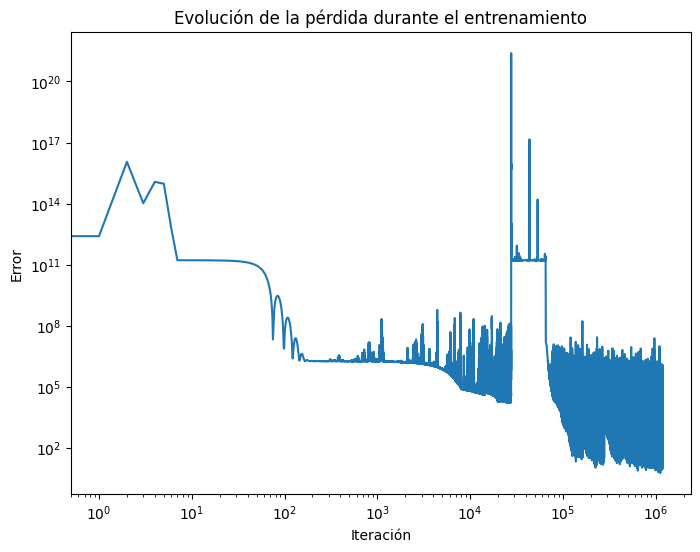

In [ ]:
# Graficar la pérdida
plt.figure(figsize=(8,6))
plt.plot(loss_history)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Iteración")
plt.ylabel("Error")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.show()

In [ ]:
date = datetime.now()
date = date.strftime("%Y%m%d%H%M%S")

# Guardar el modelo entrenado en la carpeta models
torch.save(model, f'models/model_parameters_{date}.pth')
print(f"Modelo guardado en: models/model_parameters_{date}.pth")

# Guardar la pérdida
np.savetxt(f'losses/loss_history_{date}.csv', np.array(loss_history))
print(f"Pérdida guardada en: losses/loss_history_{date}.csv")

# Guardar la configuración del modelo
config = {
    "n_determinants": model.n_determinants,
    "series_len": model.series_len,
    "wide": model.wide,
    "n_layers": model.n_layers,
    "dim_output": model.dim_output,
    "activation": model.activation.__name__,
    "total_params": total_params,
    "date": date,
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": lr
}

with open(f'configs/model_config_{date}.json', 'w') as f:
    json.dump(config, f, indent=4)
print(f"Configuración guardada en: configs/model_config_{date}.json")

Modelo guardado en: models/model_parameters_20250904065713.pth
Pérdida guardada en: losses/loss_history_20250904065713.csv
Configuración guardada en: configs/model_config_20250904065713.json


In [ ]:
# Testeo
model.eval()
with torch.no_grad():
    input_test = torch.concatenate((dets_test_tensor, wins_test_tensor, times_test_tensor), axis=1)
    SIR_pred_test = model(input_test)
    S_pred_test, I_pred_test, R_pred_test = SIR_pred_test[:, 0:1], SIR_pred_test[:, 1:2], SIR_pred_test[:, 2:3]

print("Pérdida en test:", torch.mean((I_pred_test.squeeze() - y_test_tensor)**2).item())

Pérdida en test: 27333.26171875


In [ ]:
point = X[1].copy()
point_tensor = torch.tensor(point, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
SIR_point = model(point_tensor)
grads = torch.autograd.grad(SIR_point, point_tensor, grad_outputs=torch.ones_like(SIR_point), create_graph=True)[0]

print("Gradientes:")
for i in range(len(dss_data.columns[2:])):
    print(f"{dss_data.columns[i+2]}: {grads[0,i].item()}")  # i+2 porque las primeras dos columnas no son determinantes

Gradientes:
POBTOT: 0.6878275871276855
POR_MUJ: 1.5738786458969116
POB_EDAD_0_14: -0.2533823549747467
POR_EDAD_0_14: 0.8630229234695435
POB_EDAD_15_64: 0.48949193954467773
POR_EDAD_15_64: 0.9535073637962341
POB_EDAD_65+: -0.08031046390533447
POR_EDAD_65+: 4.6340651512146
SUPERFICIE: -0.307559996843338
POR_POB_RURAL: 5.703973293304443
POR_POB_ETNIA: 17.79113006591797
POR_POBREZA_ING: 5.701195240020752
POR_POBREZA_ING_EXTR: 9.772092819213867
MARGINACION: 0.27588123083114624
IMN_num: 1.1919907331466675
REZAGO_SOCIAL_NUM: 0.35394424200057983
TASA_HOSPITALIZADOS: 1.990525245666504
TASA_MORTALIDAD: 1.2158215045928955
TASA_CASOS: 1.1643776893615723
